In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

In [2]:
markers = ['o', '*', 'v', '^', '<', 's']
sns.set_palette(palette=['#003f5c','#ff6e54','#444e86','#955196','#dd5182', '#ffa600'])
plt.rcParams.update({"text.usetex": True, "font.family" : "serif", "font.serif" : ["Computer Modern Serif"], "text.latex.preamble": "\\usepackage{textcomp}"})

In [3]:
d = pd.read_csv("../results/results.csv")

# Relevant data

In [4]:
### Number of feasible instances.
ni = len(d.instance.unique())
ni

1787

In [5]:
### Number of instances solved optimally by the compact formulation.

c_opt = len(d[(d.algorithm == 'compact') & d.optimal])
c_opt, c_opt / ni

(1400, 0.7834359261331841)

In [6]:
### Number of instances solved optimally by the extended formulation.

e_opt = len(d[(d.algorithm == 'mckp') & d.optimal])
e_opt, e_opt / ni

(1763, 0.9865696698377169)

In [7]:
### Number of instances solved optimally by the compact formulation within one second.

c_fast = len(d[(d.algorithm == 'compact') & d.optimal & (d.time_elapsed <= 1)])
c_fast, c_fast / ni

(1241, 0.6944599888080581)

In [8]:
### Number of instances solved optimally by the extended formulation within one second.

e_fast = len(d[(d.algorithm == 'mckp') & d.optimal & (d.time_elapsed <= 1)])
e_fast, e_fast / ni

(260, 0.1454952434247342)

# Performance Profile

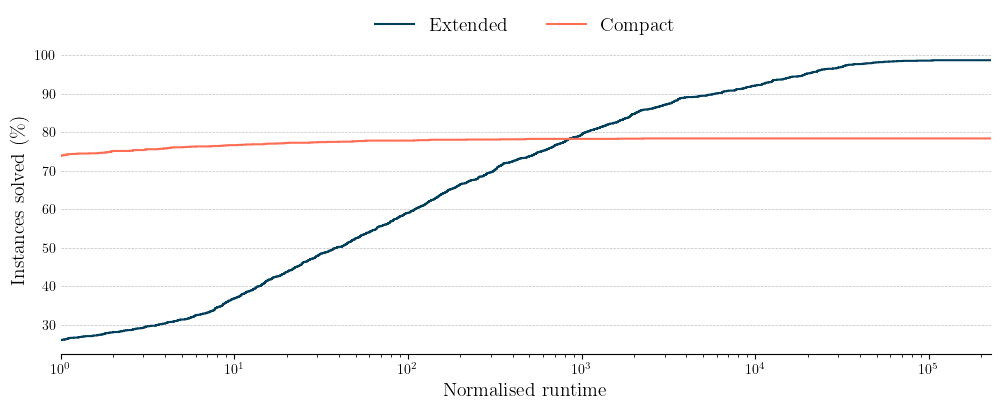

In [9]:
fig, ax = plt.subplots(figsize=(12,4))

d['fastest'] = d.groupby('instance')['time_elapsed'].transform('min')
d['runtime_ratio'] = d.time_elapsed / d.fastest
d.drop(columns='fastest', inplace=True)

for idx, algorithm in enumerate(d.algorithm.unique()):
    da = d[d.algorithm == algorithm]
    ptsx, ptsy = list(), list()

    for r in sorted(d.runtime_ratio.unique()):
        ptsx.append(r)
        ptsy.append(100 * len(da[(da.runtime_ratio <= r) & da.optimal]) / ni)

    algo_name = 'Compact' if algorithm == 'compact' else 'Extended'
    ax.step(ptsx, ptsy, color=f"C{idx}", label=algo_name)

ax.set_xlabel('Normalised runtime', fontsize=14)
ax.set_ylabel('Instances solved (\\%)', fontsize=14)
ax.set_xscale('log')
ax.set_xlim(1, d.runtime_ratio.max())

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='y', size=0)
ax.grid(which='major', axis='y', ls='--', lw=0.5, color='black', alpha=0.25)

ax.legend(ncols=2, loc='upper center', frameon=False, bbox_to_anchor=(0.5, 1.15), fontsize=14);

In [10]:
fig.savefig('performance_profile.pdf', dpi=300, bbox_inches='tight');

# Compact formulation bar chart

In [11]:
def bar_chart(algorithm: str):
    dc = d[d.algorithm == algorithm].copy()

    fig = plt.figure(constrained_layout=True, figsize=(12, 8))
    gs = fig.add_gridspec(nrows=2, ncols=2, hspace=0.05, wspace=0.1)
    ax1 = fig.add_subplot(gs[:, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1 ,1])

    ################ By kp_base ################

    ax = ax1
    kp = dc.knapsack_generator.unique()
    solved = list()
    unsolved = list()
    gap = list()

    for kpb in kp:
        dk = dc[dc.knapsack_generator == kpb]
        solved.append(100 * len(dk[dk.optimal]) / len(dk))
        unsolved.append(100 - solved[-1])

        if algorithm == 'compact':
            if len(dk[~dk.optimal]) > 0:
                gap.append(dk[~dk.optimal].gap_pct.mean())
            else:
                gap.append(0.0)

    if algorithm != 'compact':
        gap = [0] * len(kp)

    solved, unsolved, gap, kp = zip(*reversed(sorted(zip(solved, unsolved, gap, kp))))
    kpl = [' '.join(lbl.split('_')) for lbl in kp]
    kpl = [lbl.capitalize() if lbl != 'mstr' else lbl.upper() for lbl in kpl]

    ax.bar(x=range(len(kp)), height=solved, color='C5')
    ax.bar(x=range(len(kp)), height=unsolved, bottom=solved, color='C2')
    ax.set_xticks(range(len(kp)))
    ax.set_xticklabels(kpl, rotation=90, ha='center', fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(list())

    for idx, val in enumerate(solved):
        ax.text(x=idx, y=val-2, s=f"\\textbf{{{val:.0f}\\%}}", ha='center', va='top', rotation=90)

        if algorithm == 'compact' and gap[idx] > 0:
            ax.text(x=idx, y=104, s=f"{gap[idx]:.3f}", ha='center', va='top')

    if algorithm == 'compact':
        ax.text(x=0, y=104, s="\\textbf{Gap\\%~~\\textrightarrow}", ha='left', va='top')

    ################ By num_items ################

    ax = ax2
    nitems = sorted(dc.num_items.unique())
    solved = list()
    unsolved = list()
    gap = list()

    for n in nitems:
        dn = dc[dc.num_items == n]
        solved.append(100 * len(dn[dn.optimal]) / len(dn))
        unsolved.append(100 - solved[-1])

        if algorithm == 'compact':
            if len(dn[~dn.optimal]) > 0:
                gap.append(dn[~dn.optimal].gap_pct.mean())
            else:
                gap.append(0.0)

    if algorithm != 'compact':
        gap = [0] * len(kp)

    ax.bar(x=range(len(nitems)), height=solved, color='C5')
    ax.bar(x=range(len(nitems)), height=unsolved, bottom=solved, color='C2')
    ax.set_xticks(range(len(nitems)))
    ax.set_xticklabels(map(str, nitems), fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(list())
    ax.set_xlabel("Number of items", fontsize=14)

    for idx, val in enumerate(solved):
        ax.text(x=idx, y=val-2, s=f"\\textbf{{{val:.1f}\\%}}", ha='center', va='top')

        if algorithm == 'compact' and gap[idx] > 0:
            ax.text(x=idx, y=112, s=f"{gap[idx]:.3f}", ha='center', va='top')

    if algorithm == 'compact':
        ax.text(x=0, y=112, s="\\textbf{Gap\\%~~\\textrightarrow}", ha='center', va='top')

    ################ By Pisinger R ################

    ax = ax3
    pr = sorted(dc.pisinger_R.unique())
    solved = list()
    unsolved = list()
    gap = list()

    for p in pr:
        dp = dc[dc.pisinger_R == p]
        solved.append(100 * len(dp[dp.optimal]) / len(dp))
        unsolved.append(100 - solved[-1])

        if algorithm == 'compact':
            if len(dp[~dp.optimal]) > 0:
                gap.append(dp[~dp.optimal].gap_pct.mean())
            else:
                gap.append(0.0)

    if algorithm != 'compact':
        gap = [0] * len(kp)

    ax.bar(x=range(len(pr)), height=solved, color='C5')
    ax.bar(x=range(len(pr)), height=unsolved, bottom=solved, color='C2')
    ax.set_xticks(range(len(pr)))
    ax.set_xticklabels(map(str, pr), fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(list())
    ax.set_xlabel("Data range $R$", fontsize=14)

    for idx, val in enumerate(solved):
        ax.text(x=idx, y=val-2, s=f"\\textbf{{{val:.1f}\\%}}", ha='center', va='top')

        if algorithm == 'compact' and gap[idx] > 0:
            ax.text(x=idx, y=112, s=f"{gap[idx]:.3f}", ha='center', va='top')

    if algorithm == 'compact':
        ax.text(x=2, y=112, s="\\textbf{\\textleftarrow~~Gap\\%}", ha='center', va='top')

    ################ Legend ################

    h = [Rectangle(xy=[0,0], height=5, width=10, facecolor=c, edgecolor='k') for c in ('C2', 'C5')]
    fig.legend(h, ["Not optimal", "Optimal"], ncols=2, title=None, fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.1), frameon=False)

    return fig, (ax1, ax2, ax3)

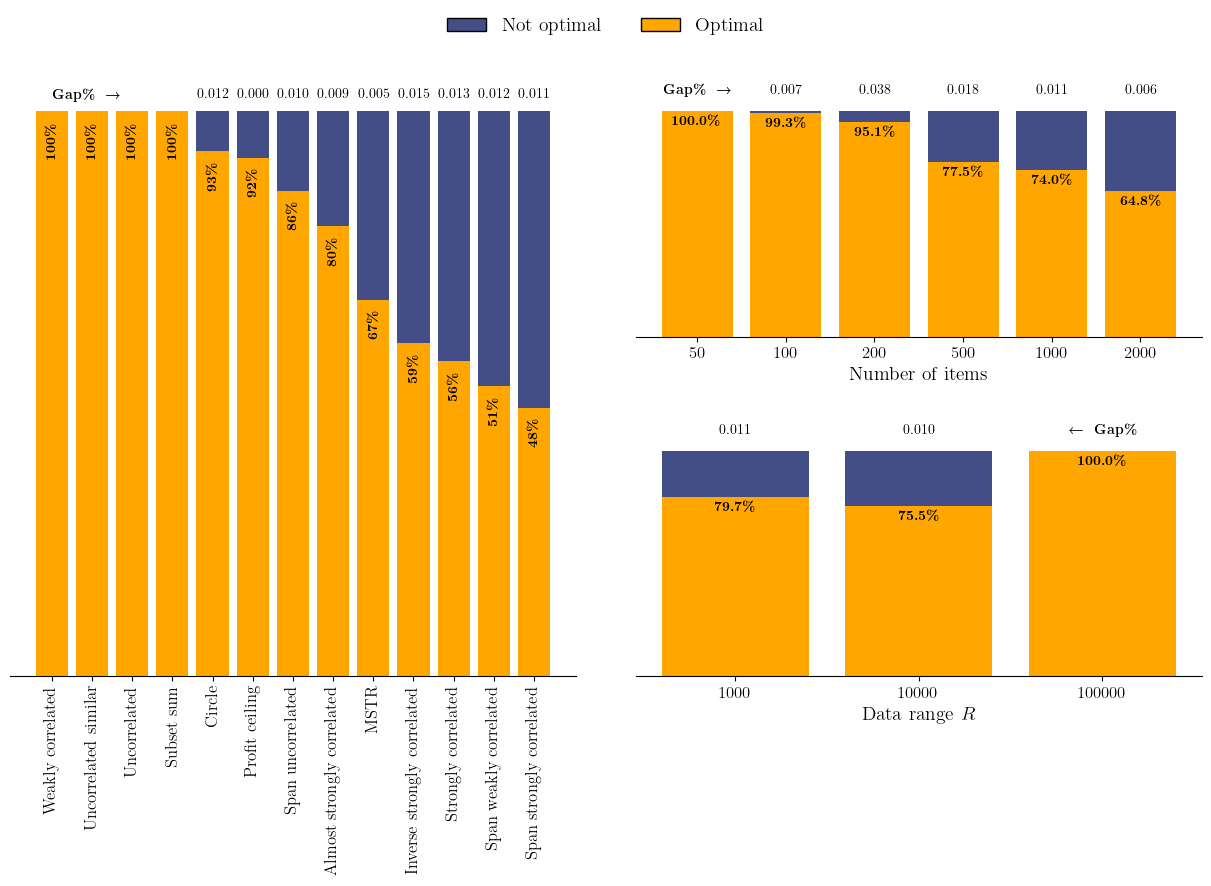

In [12]:
fig, ax = bar_chart(algorithm='compact')

In [13]:
fig.savefig('compact_res.pdf', dpi=300, bbox_inches='tight');

# Extended formulation bar chart

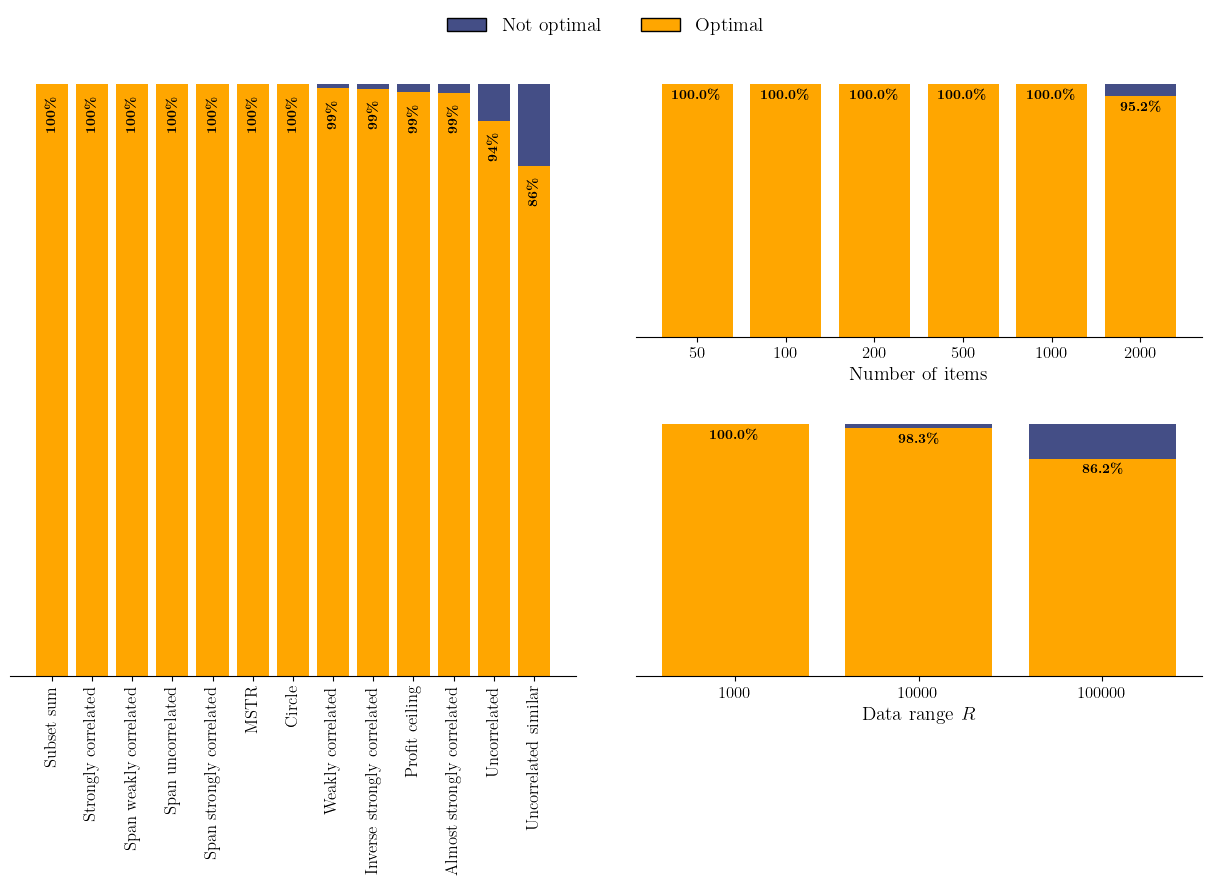

In [14]:
fig, ax = bar_chart(algorithm='mckp')

In [15]:
fig.savefig('extended_res.pdf', dpi=300, bbox_inches='tight');